# **SIGK Denoising**

### Import Dataset DIV2K

In [1]:
import os
from typing import Any, Tuple
import cv2
import numpy as np
import torch
from torch.utils.data import Dataset
from torchvision import transforms


class ImageDataset(Dataset):
    def __init__(self, root: str, noise_level: float = None, input_size: Tuple[int, int] = None):
        self.root = root
        self.image_paths = [
            os.path.join(root, f) for f in os.listdir(root) if f.endswith(".png")
        ]
        self.transform = transforms.ToTensor()
        if noise_level and input_size:
            raise ValueError("Only one value can be set at the same time.")
        self.noise_level = noise_level
        self.input_size = input_size

    def __len__(self) -> int:
        return len(self.image_paths)

    def __getitem__(self, idx) -> Tuple[torch.Tensor, torch.Tensor]:
        img_path = self.image_paths[idx]
        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = self.__resize(img, (256, 256))
        if self.input_size is not None:
            modified_img = self.__resize(img, self.input_size)
            modified_img = modified_img.astype(np.float32) / 255.0
            modified_img = self.transform(modified_img)

        img = img.astype(np.float32) / 255.0
        img = self.transform(img)

        if self.noise_level is not None:
            modified_img = self.__add_noise(img, self.noise_level)

        return modified_img, img

    def __add_noise(self, img: torch.Tensor, noise_level: float = 0.1) -> torch.Tensor:
        noise = torch.randn_like(img) * noise_level
        noisy_img = img + noise
        noisy_img = torch.clamp(noisy_img, 0.0, 1.0)
        return noisy_img

    def __resize(self, img: Any, size: Tuple[int, int]) -> Any:
        img = cv2.resize(img, size)
        return img

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
%env DATASET_PATH=/content/drive/MyDrive/SIGK

env: DATASET_PATH=/content/drive/MyDrive/SIGK


In [4]:
from torch.utils.data import DataLoader

noise = 0.1

train_dataset = ImageDataset(f"{os.getenv('DATASET_PATH')}/DIV2K_train_HR", noise)
train_dataloader = DataLoader(train_dataset, batch_size=16, shuffle=False, num_workers=0)

valdiation_dataset = ImageDataset(f"{os.getenv('DATASET_PATH')}/DIV2K_valid_HR", noise)
valdiation_dataloader = DataLoader(valdiation_dataset, batch_size=16, shuffle=False, num_workers=0)

Example dataset images

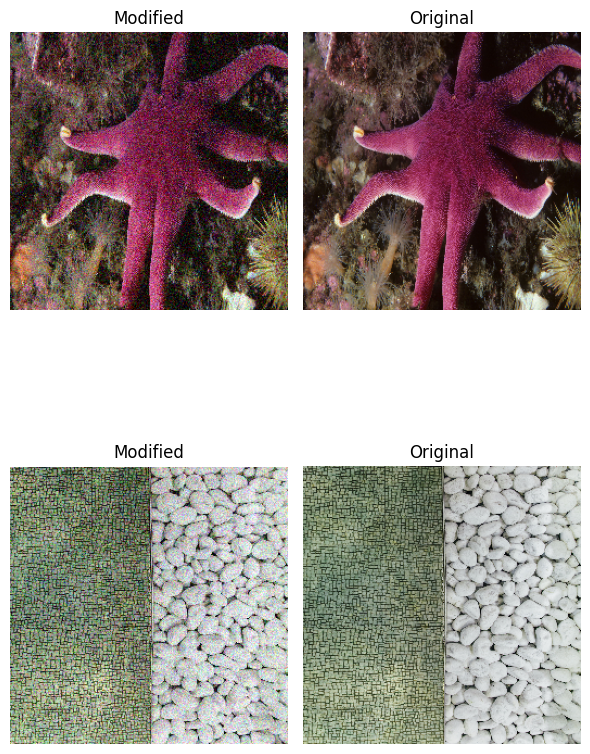

In [5]:
import matplotlib.pyplot as plt

x, y = next(iter(train_dataloader))

num_samples = 2
fig, axs = plt.subplots(num_samples, 2, figsize=(6, 10))

for i in range(num_samples):
    axs[i, 0].imshow(x[i].permute(1, 2, 0))
    axs[i, 0].set_title("Noisy")
    axs[i, 0].axis("off")

    axs[i, 1].imshow(y[i].permute(1, 2, 0))
    axs[i, 1].set_title("Original")
    axs[i, 1].axis("off")

plt.tight_layout()
plt.show()

### Denoising model UNET


In [131]:
import torch
import torch.nn as nn
from typing import Optional

class UNet(nn.Module):

    def __init__(
        self,
        in_channels: int = 3,
        out_channels: int = None,
        init_features: int = 64,
        use_bnorm: bool = True,
    ):
        super(UNet, self).__init__()

        if out_channels is None:
            out_channels = in_channels

        self.in_channels = in_channels
        self.out_channels = out_channels
        self.init_features = init_features
        self.use_bnorm = use_bnorm

        features = init_features

        self.encoder1 = self._make_layer(in_channels, features, use_bnorm)
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2)

        self.encoder2 = self._make_layer(features, features * 2, use_bnorm)
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2)

        self.encoder3 = self._make_layer(features * 2, features * 4, use_bnorm)
        self.pool3 = nn.MaxPool2d(kernel_size=2, stride=2)

        self.encoder4 = self._make_layer(features * 4, features * 8, use_bnorm)
        self.pool4 = nn.MaxPool2d(kernel_size=2, stride=2)

        self.bottleneck = self._make_layer(features * 8, features * 16, use_bnorm)

        self.upconv4 = nn.ConvTranspose2d(features * 16, features * 8, kernel_size=2, stride=2)
        self.decoder4 = self._make_layer(features * 16, features * 8, use_bnorm)

        self.upconv3 = nn.ConvTranspose2d(features * 8, features * 4, kernel_size=2, stride=2)
        self.decoder3 = self._make_layer(features * 8, features * 4, use_bnorm)

        self.upconv2 = nn.ConvTranspose2d(features * 4, features * 2, kernel_size=2, stride=2)
        self.decoder2 = self._make_layer(features * 4, features * 2, use_bnorm)

        self.upconv1 = nn.ConvTranspose2d(features * 2, features, kernel_size=2, stride=2)
        self.decoder1 = self._make_layer(features * 2, features, use_bnorm)

        self.conv_out = nn.Conv2d(features, out_channels, kernel_size=1)

    def _make_layer(self, in_channels: int, out_channels: int, use_bnorm: bool):
        layers = [
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1, bias=not use_bnorm),
            nn.BatchNorm2d(out_channels) if use_bnorm else nn.Identity(),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1, bias=not use_bnorm),
            nn.BatchNorm2d(out_channels) if use_bnorm else nn.Identity(),
            nn.ReLU(inplace=True)
        ]
        return nn.Sequential(*layers)

    def forward(self, x):

        enc1 = self.encoder1(x)
        enc2 = self.encoder2(self.pool1(enc1))
        enc3 = self.encoder3(self.pool2(enc2))
        enc4 = self.encoder4(self.pool3(enc3))

        bottleneck = self.bottleneck(self.pool4(enc4))

        dec4 = self.upconv4(bottleneck)
        dec4 = torch.cat([dec4, enc4], dim=1)
        dec4 = self.decoder4(dec4)

        dec3 = self.upconv3(dec4)
        dec3 = torch.cat([dec3, enc3], dim=1)
        dec3 = self.decoder3(dec3)

        dec2 = self.upconv2(dec3)
        dec2 = torch.cat([dec2, enc2], dim=1)
        dec2 = self.decoder2(dec2)

        dec1 = self.upconv1(dec2)
        dec1 = torch.cat([dec1, enc1], dim=1)
        dec1 = self.decoder1(dec1)

        output = self.conv_out(dec1)

        return output

UNET loss functions

In [7]:
"""
Loss functions for image denoising
Includes Perceptual Loss and Charbonnier Loss
"""

import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision.models import vgg16


class CharbonnierLoss(nn.Module):

    def __init__(self, epsilon: float = 1e-3, reduction: str = 'mean'):
        super(CharbonnierLoss, self).__init__()
        self.epsilon = epsilon
        self.reduction = reduction

    def forward(self, pred: torch.Tensor, target: torch.Tensor) -> torch.Tensor:
        diff = pred - target
        loss = torch.sqrt(diff * diff + self.epsilon * self.epsilon)

        return torch.mean(loss)


class PerceptualLoss(nn.Module):
    def __init__(self):
        super(PerceptualLoss, self).__init__()
        vgg = vgg16(pretrained=True).features[:16]
        for param in vgg.parameters():
            param.requires_grad = False
        self.vgg = vgg.eval()

    def forward(self, denoised, gt):
        denoised_features = self.vgg(denoised)
        gt_features = self.vgg(gt)
        loss = F.mse_loss(denoised_features, gt_features)
        return loss


class CombinedLoss(nn.Module):

    def __init__(
        self,
        charbonnier_loss: nn.Module,
        perceptual_loss: nn.Module,
        mse_weight: float = 1.0,
        charbonnier_weight: float = 1.0,
        perceptual_weight: float = 0.1
    ):
        super(CombinedLoss, self).__init__()
        self.mse_weight = mse_weight
        self.charbonnier_loss = charbonnier_loss
        self.perceptual_loss = perceptual_loss
        self.charbonnier_weight = charbonnier_weight
        self.perceptual_weight = perceptual_weight

    def forward(self, pred: torch.Tensor, target: torch.Tensor) -> torch.Tensor:
        mse_loss = nn.MSELoss()(pred, target)
        loss = self.charbonnier_weight * self.charbonnier_loss(pred, target)
        loss += mse_loss * self.mse_weight
        if self.perceptual_loss is not None:
            loss += self.perceptual_weight * self.perceptual_loss(pred, target)

        return loss


def get_charbonnier_loss() -> CharbonnierLoss:
    return CharbonnierLoss()


def get_perceptual_loss(
) -> PerceptualLoss:
    return PerceptualLoss()


def get_combined_loss(
    pixel_weight: float = 1.0,
    perceptual_weight: float = 0.1,
) -> CombinedLoss:
    pixel_loss = get_charbonnier_loss()
    perceptual_loss = get_perceptual_loss()
    return CombinedLoss(pixel_loss, perceptual_loss, pixel_weight, perceptual_weight)

In [8]:
import torch
import time
from tqdm import tqdm
import random
import numpy as np

def set_seed(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

def train_epoch(model, loader, criterion, optimizer, device, epoch=None):
    model.train()
    total_loss = 0
    start_time = time.time()

    for batch_idx, (x, y) in tqdm(enumerate(loader)):
        x, y = x.to(device), y.to(device)

        optimizer.zero_grad()
        outputs = model(x)
        loss = criterion(outputs, y)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

        if batch_idx % 10 == 0:
            print(f"Epoch {epoch}, Batch {batch_idx}/{len(loader)}, "
                       f"Batch Loss: {loss.item():.6f}")

    avg_loss = total_loss / len(loader)
    epoch_time = time.time() - start_time
    print(f"Epoch {epoch} Training - Avg Loss: {avg_loss:.6f}, "
                   f"Time: {epoch_time:.2f}s")

    return avg_loss

def validate(model, loader, criterion, device, epoch=None):
    model.eval()
    total_loss = 0
    batch_count = 0

    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            outputs = model(x)
            loss = criterion(outputs, y)

            total_loss += loss.item()
            batch_count += 1

    avg_loss = total_loss / batch_count
    print(f"Epoch {epoch} Validation - Loss: {avg_loss:.6f}")

    return avg_loss

UNET Training function

In [15]:
import torch
from torch.utils.data import DataLoader
import time
from datetime import datetime


def train_model(data, model, device, epochs=7):
    train_loader = data

    criterion = CombinedLoss(
        charbonnier_loss=CharbonnierLoss(),
        perceptual_loss=PerceptualLoss().to(device),
        mse_weight=1.0,
        charbonnier_weight=0.5,
        perceptual_weight=0.1
    ).to(device)

    print("Loss Configuration:")
    print("Combined Loss: MSE(1.0) + Charbonnier(0.5) + Perceptual(0.1)")

    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=1e-4,
        weight_decay=1e-5
    )

    print("Optimizer: Adam, LR: 1e-4, Weight Decay: 1e-5")
    print("-" * 80)

    best_val_loss = float("inf")
    training_start_time = time.time()

    for epoch in range(epochs):
        epoch_start_time = time.time()
        print(f"Starting Epoch {epoch + 1}/{epochs}")

        train_loss = train_epoch(model, train_loader, criterion, optimizer, device, epoch + 1)

        epoch_time = time.time() - epoch_start_time
        total_time = time.time() - training_start_time

        print(f"Epoch {epoch + 1} Summary:")
        print(f"  Train Loss: {train_loss:.6f}")
        print(f"  Epoch Time: {epoch_time:.2f}s")
        print(f"  Total Time: {total_time:.2f}s")
        print(f"  Estimated remaining: {(total_time / (epoch + 1) * (epochs - epoch - 1)):.2f}s")

        print("-" * 40)

    total_training_time = time.time() - training_start_time
    print(f"Best validation loss: {best_val_loss:.6f}")
    model_filename = "best_model_unet_init"
    model_filename += ".pth"
    torch.save(model.state_dict(), model_filename)
    print(f"Final model saved as: {model_filename}")

    print("="*80)
    print("TRAINING COMPLETED")
    print(f"Total training time: {total_training_time:.2f}s ({total_training_time/60:.1f} min)")
    print(f"Average time per epoch: {total_training_time/epochs:.2f}s")
    print(f"Best validation loss: {best_val_loss:.6f}")
    print(f"Final model saved as: {model_filename}")

    return best_val_loss

# Training UNET model

In [16]:
epochs = 7

print("="*80)
print("U-Net Training Experiment")
print(f"Epochs: {epochs}")
print(f"Start Time: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")

print("="*80)

set_seed(42)

print(f"Total images found: {len(train_dataset)}")


print("Starting training...")
experiment_start_time = time.time()

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = UNet(
    in_channels=3,
    init_features=128,
    use_bnorm=True,
).to(device)

best_training_loss = train_model(train_dataloader, model, device, epochs)

experiment_total_time = time.time() - experiment_start_time

print("="*80)
print("EXPERIMENT COMPLETED")
print(f"Total experiment time: {experiment_total_time:.2f}s ({experiment_total_time/60:.1f} min)")
print(f"Best training loss: {best_training_loss:.6f}")
print(f"End Time: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print("="*80)

U-Net Training Experiment
Epochs: 7
Start Time: 2025-11-02 13:08:27
Total images found: 800
Starting training...


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG16_Weights.IMAGENET1K_V1`. You can also use `weights=VGG16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Loss Configuration:
Combined Loss: MSE(1.0) + Charbonnier(0.5) + Perceptual(0.1)
Optimizer: Adam, LR: 1e-4, Weight Decay: 1e-5
--------------------------------------------------------------------------------
Starting Epoch 1/7


1it [00:03,  3.07s/it]

Epoch 1, Batch 0/50, Batch Loss: 1.068537


...

Epoch 7, Batch 30/50, Batch Loss: 0.137384


41it [02:01,  2.98s/it]

Epoch 7, Batch 40/50, Batch Loss: 0.144608


50it [02:28,  2.96s/it]


Epoch 7 Training - Avg Loss: 0.139737, Time: 148.05s
Epoch 7 Summary:
  Train Loss: 0.139737
  Epoch Time: 148.05s
  Total Time: 1036.55s
  Estimated remaining: 0.00s
----------------------------------------
Best validation loss: inf
Final model saved as: best_model_unet_init.pth
TRAINING COMPLETED
Total training time: 1036.55s (17.3 min)
Average time per epoch: 148.08s
Best validation loss: inf
Final model saved as: best_model_unet_init.pth
EXPERIMENT COMPLETED
Total experiment time: 1039.93s (17.3 min)
Best training loss: inf
End Time: 2025-11-02 13:25:47


In [146]:
def denoise_image(model, image, device):
    model.eval()
    with torch.no_grad():
        noisy_image = image.to(device)
        denoised = model(noisy_image)

    return denoised

def visualize_image(original, noisy, denoised, n=2):

    original = original.permute(0, 2, 3, 1).cpu()
    noisy    = noisy.permute(0, 2, 3, 1).cpu()
    denoised = denoised.permute(0, 2, 3, 1).cpu()

    k = min(n, len(original), len(noisy), len(denoised))
    for i in range(k):
        fig, axes = plt.subplots(1, 3, figsize=(12, 4))
        axes[0].imshow(noisy[i].clip(0, 1).squeeze())       # handles 1-ch too
        axes[0].set_title("Noisy")
        axes[0].axis("off")

        axes[1].imshow(denoised[i].clip(0, 1).squeeze())
        axes[1].set_title("Denoised")
        axes[1].axis("off")

        axes[2].imshow(original[i].clip(0, 1).squeeze())
        axes[2].set_title("Ground Truth")
        axes[2].axis("off")

        plt.tight_layout()
        plt.show()


In [44]:
import gc
gc.collect()
torch.cuda.empty_cache()

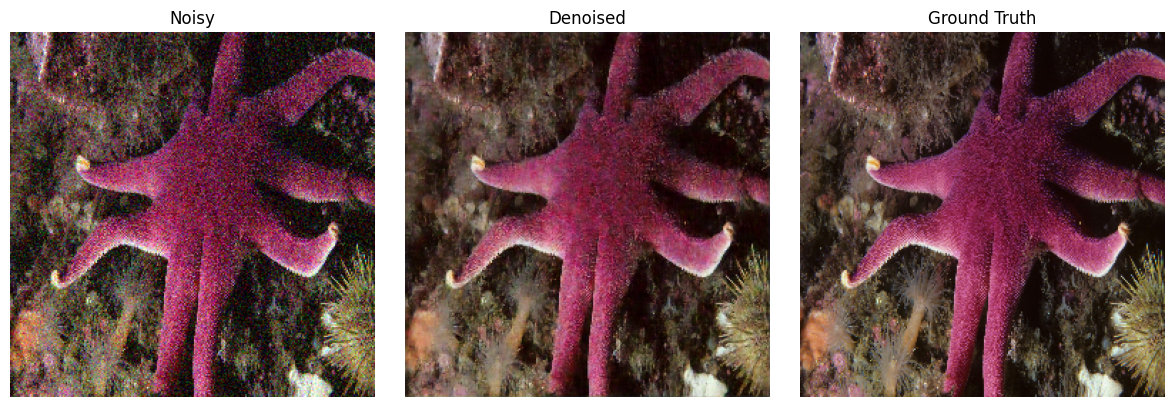

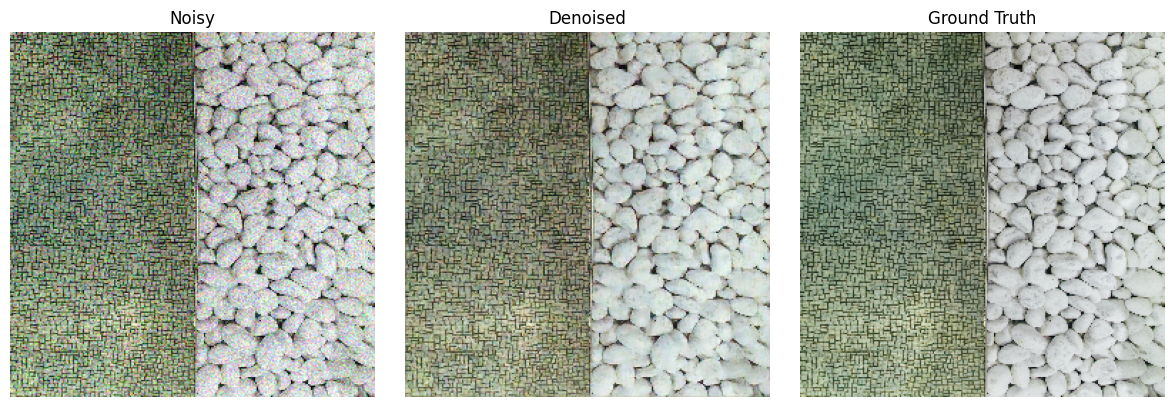

In [147]:
noisy_image, original_image = next(iter(train_dataloader))

denoised_image = denoise_image(model, noisy_image, device)
visualize_image(original_image, noisy_image, denoised_image)

### Evaluating metrics for UNET model

In [24]:
!pip install -q lpips

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.8/53.8 kB 3.0 MB/s eta 0:00:00


In [122]:
import math
import numpy as np
from math import log10, sqrt
from skimage.metrics import structural_similarity as ssim
import lpips
from torch.utils.data import DataLoader

def SNE(original, generated):
    mse = ((original - generated) ** 2).mean()
    return mse

def evaluate_SNE(model: nn.Module, data: DataLoader, device: str):
    model.eval()
    total_score = 0
    num_batches = 0
    with torch.no_grad():
        for modified_img, original_img in data:
            modified_img, original_img = modified_img.to(device), original_img.to(device)
            generated_img = model(modified_img)

            score = SNE(generated_img, original_img)

            total_score += score
            num_batches += 1
    average_score = total_score / num_batches
    print(f"Average SNE: {average_score:.6f}")
    return average_score

def PSNR(original, generated):
    mse = SNE(original, generated)
    if(mse == 0):
        return float("inf")
    max_pixel = 1
    psnr = 20 * log10(max_pixel / sqrt(mse))
    return psnr


def evaluate_PSNR(model: nn.Module, data: DataLoader, device: str):
    model.eval()
    total_score = 0
    num_batches = 0
    with torch.no_grad():
        for modified_img, original_img in data:
            modified_img, original_img = modified_img.to(device), original_img.to(device)
            generated_img = model(modified_img)

            score = PSNR(generated_img, original_img)
            print(num_batches)
            total_score += score
            num_batches += 1
    average_score = total_score / num_batches
    print(f"Average PSNR: {average_score:.2f} dB")
    return average_score

def SSIM(original: torch.Tensor, generated: torch.Tensor) -> float:
    original_np = original.detach().cpu().clamp(0, 1).permute(1, 2, 0).numpy()
    generated_np = generated.detach().cpu().clamp(0, 1).permute(1, 2, 0).numpy()

    score = ssim(original_np, generated_np, data_range=1.0, channel_axis=2)
    return float(score)



def evaluate_SSIM(model: torch.nn.Module, data: torch.utils.data.DataLoader, device: str) -> float:
    model.eval()
    total_score = 0.0
    num_images = 0

    for modified_img, original_img in data:
        modified_img = modified_img.to(device)
        original_img = original_img.to(device)
        generated_img = model(modified_img)

        for i in range(generated_img.size(0)):
            score = SSIM(generated_img[i], original_img[i])
            total_score += score
            num_images += 1

    average_score = total_score / max(num_images, 1)
    print(f"Average SSIM: {average_score:.4f}")
    return average_score


def evaluate_LPIPS(model: nn.Module, data: DataLoader, device: str):

    model.eval()
    total_score = 0
    num_batches = 0
    with torch.no_grad():
        for modified_img, original_img in data:
            modified_img, original_img = modified_img.to(device), original_img.to(device)
            generated_img = model(modified_img)

            LPIPS = lpips.LPIPS(net='vgg').to(device)
            score = (LPIPS(generated_img, original_img)).mean()
            print(score)
            total_score += score
            num_batches += 1
    average_score = total_score / num_batches
    print(f"Average LPIPS: {average_score:.4f}")
    return average_score


In [60]:
import gc
gc.collect()
torch.cuda.empty_cache()

In [58]:
avg_psnr = evaluate_PSNR(model, valdiation_dataloader, device)
avg_sne = evaluate_SNE(model, valdiation_dataloader, device)

Average PSNR: 21.91 dB
Average SNE: 0.008339


In [59]:
avg_ssim = evaluate_SSIM(model, valdiation_dataloader, device)
torch.cuda.empty_cache()

Average SSIM: 0.8050


In [69]:
avg_lpips = evaluate_LPIPS(model, valdiation_dataloader, device)

Setting up [LPIPS] perceptual loss: trunk [vgg], v[0.1], spatial [off]
Loading model from: /usr/local/lib/python3.12/dist-packages/lpips/weights/v0.1/vgg.pth
tensor(0.1997, device='cuda:0')
Setting up [LPIPS] perceptual loss: trunk [vgg], v[0.1], spatial [off]
Loading model from: /usr/local/lib/python3.12/dist-packages/lpips/weights/v0.1/vgg.pth
tensor(0.1942, device='cuda:0')
Setting up [LPIPS] perceptual loss: trunk [vgg], v[0.1], spatial [off]
Loading model from: /usr/local/lib/python3.12/dist-packages/lpips/weights/v0.1/vgg.pth
tensor(0.2116, device='cuda:0')
Setting up [LPIPS] perceptual loss: trunk [vgg], v[0.1], spatial [off]
Loading model from: /usr/local/lib/python3.12/dist-packages/lpips/weights/v0.1/vgg.pth
tensor(0.2148, device='cuda:0')
Setting up [LPIPS] perceptual loss: trunk [vgg], v[0.1], spatial [off]
Loading model from: /usr/local/lib/python3.12/dist-packages/lpips/weights/v0.1/vgg.pth
tensor(0.2015, device='cuda:0')
Setting up [LPIPS] perceptual loss: trunk [vgg], v

### Built in denoising method

In [116]:
import torch
import torch.nn as nn
import numpy as np
from skimage.restoration import denoise_bilateral


class DenoiseBilateral(nn.Module):
    def __init__(self):
        super().__init__()

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        device = x.device
        x_np = x.detach().cpu().numpy()  # shape (B, C, H, W)
        denoised_batch = []

        for img in x_np:
            img = np.moveaxis(img, 0, -1)  # (C, H, W) -> (H, W, C)
            denoised = denoise_bilateral(img, channel_axis=-1)
            denoised = np.moveaxis(denoised, -1, 0)  # back to (C, H, W)
            denoised_batch.append(denoised)

        denoised_batch = np.stack(denoised_batch, axis=0)  # (B, C, H, W)
        return torch.tensor(denoised_batch, dtype=torch.float32, device=device)

### Comparison of UNET model to denoise bilateral method from skimage

In [117]:
noisy_image, original_image = next(iter(train_dataloader))

In [151]:
BilateralDenoiser = DenoiseBilateral().to(device)

denoised_images_with_bilateral = denoise_image(BilateralDenoiser, noisy_image, device)
denoised_images_with_model = denoise_image(model, noisy_image, device)

In [154]:
def compare_images(original, noisy, denoised_bilateral, denoised_model, n=2):

    original = original.permute(0, 2, 3, 1).cpu()
    noisy    = noisy.permute(0, 2, 3, 1).cpu()
    denoised_model = denoised_model.permute(0, 2, 3, 1).cpu()
    denoised_bilateral = denoised_bilateral.permute(0, 2, 3, 1).cpu()

    k = min(n, len(original), len(noisy), len(denoised_bilateral))
    for i in range(k):
        fig, axes = plt.subplots(1, 4, figsize=(12, 4))
        axes[0].imshow(noisy[i].clip(0, 1).squeeze())
        axes[0].set_title("Noisy")
        axes[0].axis("off")

        axes[1].imshow(denoised_model[i].clip(0, 1).squeeze())
        axes[1].set_title("Denoised with UNET")
        axes[1].axis("off")

        axes[2].imshow(denoised_bilateral[i].clip(0, 1).squeeze())
        axes[2].set_title("Denoised with bilateral")
        axes[2].axis("off")

        axes[3].imshow(original[i].clip(0, 1).squeeze())
        axes[3].set_title("Ground Truth")
        axes[3].axis("off")

        plt.tight_layout()
        plt.show()


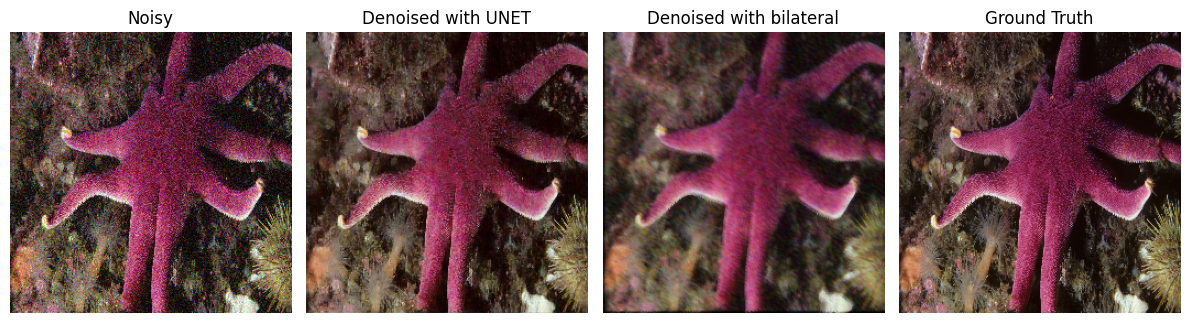

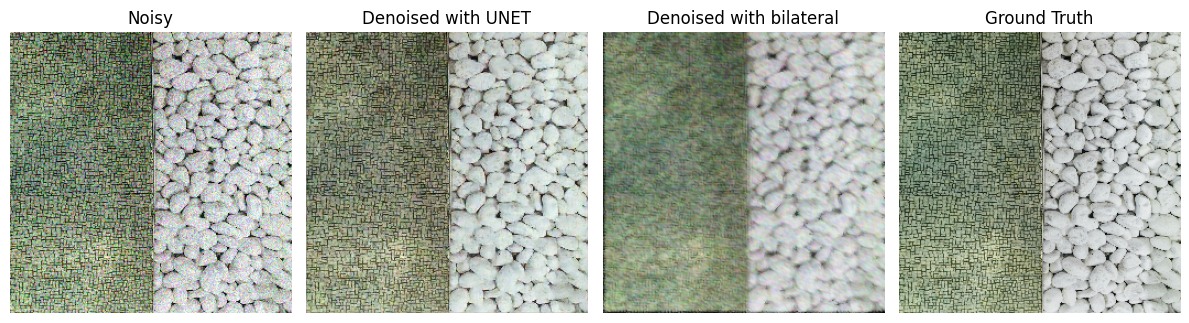

In [155]:
compare_images(original_image, noisy_image, denoised_images_with_bilateral, denoised_images_with_model)

In [121]:
avg_psnr_bilateral = evaluate_PSNR(BilateralDenoiser, valdiation_dataloader, device)
avg_sne_bilateral = evaluate_SNE(BilateralDenoiser, valdiation_dataloader, device)

Start PSNR evaluation
Evaluate image
0
Evaluate image
1
Evaluate image
2
Evaluate image
3
Evaluate image
4
Evaluate image
5
Evaluate image
6
Average PSNR: 17.85 dB
Average SNE: 0.016873


In [123]:
avg_ssim_bilateral = evaluate_SSIM(BilateralDenoiser, valdiation_dataloader, device)
torch.cuda.empty_cache()

Average SSIM: 0.3921


In [124]:
avg_lpips_bilateral = evaluate_LPIPS(BilateralDenoiser, valdiation_dataloader, device)

Setting up [LPIPS] perceptual loss: trunk [vgg], v[0.1], spatial [off]


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG16_Weights.IMAGENET1K_V1`. You can also use `weights=VGG16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Loading model from: /usr/local/lib/python3.12/dist-packages/lpips/weights/v0.1/vgg.pth
tensor(0.4401, device='cuda:0')
Setting up [LPIPS] perceptual loss: trunk [vgg], v[0.1], spatial [off]
Loading model from: /usr/local/lib/python3.12/dist-packages/lpips/weights/v0.1/vgg.pth
tensor(0.4501, device='cuda:0')
Setting up [LPIPS] perceptual loss: trunk [vgg], v[0.1], spatial [off]
Loading model from: /usr/local/lib/python3.12/dist-packages/lpips/weights/v0.1/vgg.pth
tensor(0.4566, device='cuda:0')
Setting up [LPIPS] perceptual loss: trunk [vgg], v[0.1], spatial [off]
Loading model from: /usr/local/lib/python3.12/dist-packages/lpips/weights/v0.1/vgg.pth
tensor(0.4483, device='cuda:0')
Setting up [LPIPS] perceptual loss: trunk [vgg], v[0.1], spatial [off]
Loading model from: /usr/local/lib/python3.12/dist-packages/lpips/weights/v0.1/vgg.pth
tensor(0.4643, device='cuda:0')
Setting up [LPIPS] perceptual loss: trunk [vgg], v[0.1], spatial [off]
Loading model from: /usr/local/lib/python3.12/dist

Denoise bilateral vs UNET metrics

In [126]:
print("Compare Bilateral Denoiser vs UNET net")
print("PSNR")
print(f"Bilateral denoiser: {avg_psnr_bilateral:.2f}dB || UNET: {avg_psnr:.2f}dB")

Compare Bilateral Denoiser vs UNET net
PSNR
Bilateral denoiser: 17.85dB || UNET: 21.91dB


In [127]:
print("SNE")
print(f"Bilateral denoiser: {avg_sne_bilateral:.2f} || UNET: {avg_sne:.2f}")

SNE
Bilateral denoiser: 0.02 || UNET: 0.01


In [128]:
print("SSIM")
print(f"Bilateral denoiser: {avg_ssim_bilateral:.2f} || UNET: {avg_ssim:.2f}")

SSIM
Bilateral denoiser: 0.39 || UNET: 0.81


In [129]:
print("LPIPS")
print(f"Bilateral denoiser: {avg_lpips_bilateral:.2f} || UNET: {avg_lpips:.2f}")

LPIPS
Bilateral denoiser: 0.44 || UNET: 0.20
